In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


label: 26a1
label: 26b1
lenn: 503
deformed_h_list[0]: 1
n: 1 elapsed: 0.04012983242670695
n: 2 elapsed: 0.04014753500620524
n: 3 elapsed: 0.04015514850616455
n: 4 elapsed: 0.04016504685084025
n: 5 elapsed: 0.040179518858591716
n: 6 elapsed: 0.04020143349965413
n: 7 elapsed: 0.040220550696055096
n: 8 elapsed: 0.04024539788564046
n: 9 elapsed: 0.0402823011080424
n: 10 elapsed: 0.040318600336710614
n: 11 elapsed: 0.04036419788996379
n: 12 elapsed: 0.04041573206583659
n: 13 elapsed: 0.04047713279724121
n: 14 elapsed: 0.04055388371149699
n: 15 elapsed: 0.04064363241195679
n: 16 elapsed: 0.04073620239893595
n: 17 elapsed: 0.040865453084309895
n: 18 elapsed: 0.04099043210347494
n: 19 elapsed: 0.041140615940093994
n: 20 elapsed: 0.041290215651194256
n: 21 elapsed: 0.04149155219395955
n: 22 elapsed: 0.04167850017547607
n: 23 elapsed: 0.04186531702677409
n: 24 elapsed: 0.042102253437042235
n: 25 elapsed: 0.042377881209055585
n: 26 elapsed: 0.04264076550801595
n: 27 elapsed: 0.04291643301645915
n

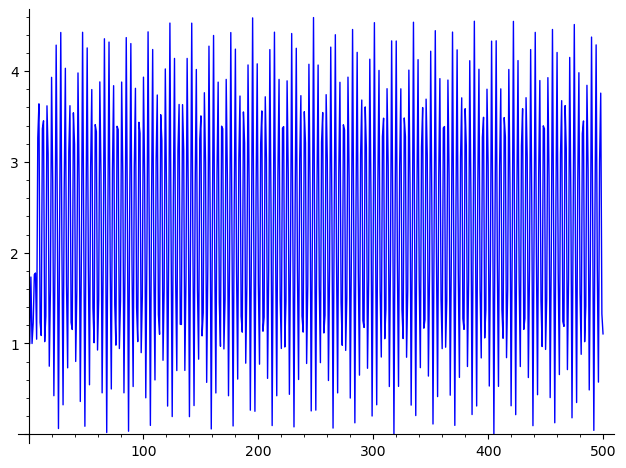

Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.000692 to 4.590282

Stage A: degree-2 polynomial detrend
  lag-1 autocorrelation of residuals: -0.0776
  ACF crosses zero within 166 lags: True
  --> Residual is oscillatory or low-autocorrelation. Polynomial detrend is sufficient.

Final detrending method: Polynomial (degree 2)
  Detrended data std dev: 1.3182

AR(1) lag-1 autocorrelation (rho): -0.0776
Frequency bins tested: 247
Bonferroni-corrected per-bin alpha: 95% -> 0.000202,  99% -> 0.000040

SIGNIFICANT FFT PEAKS  (period <= N/3 = 167, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            3.79   0.264000     1.42e+05   99%

MULTI-SCALE PERIOD DETECTION
  Period       Scale           ACF strength    Role                
  ------------------------------------------------------------
      57.0    MA(55)              0.5977      FUNDAMENTAL
  

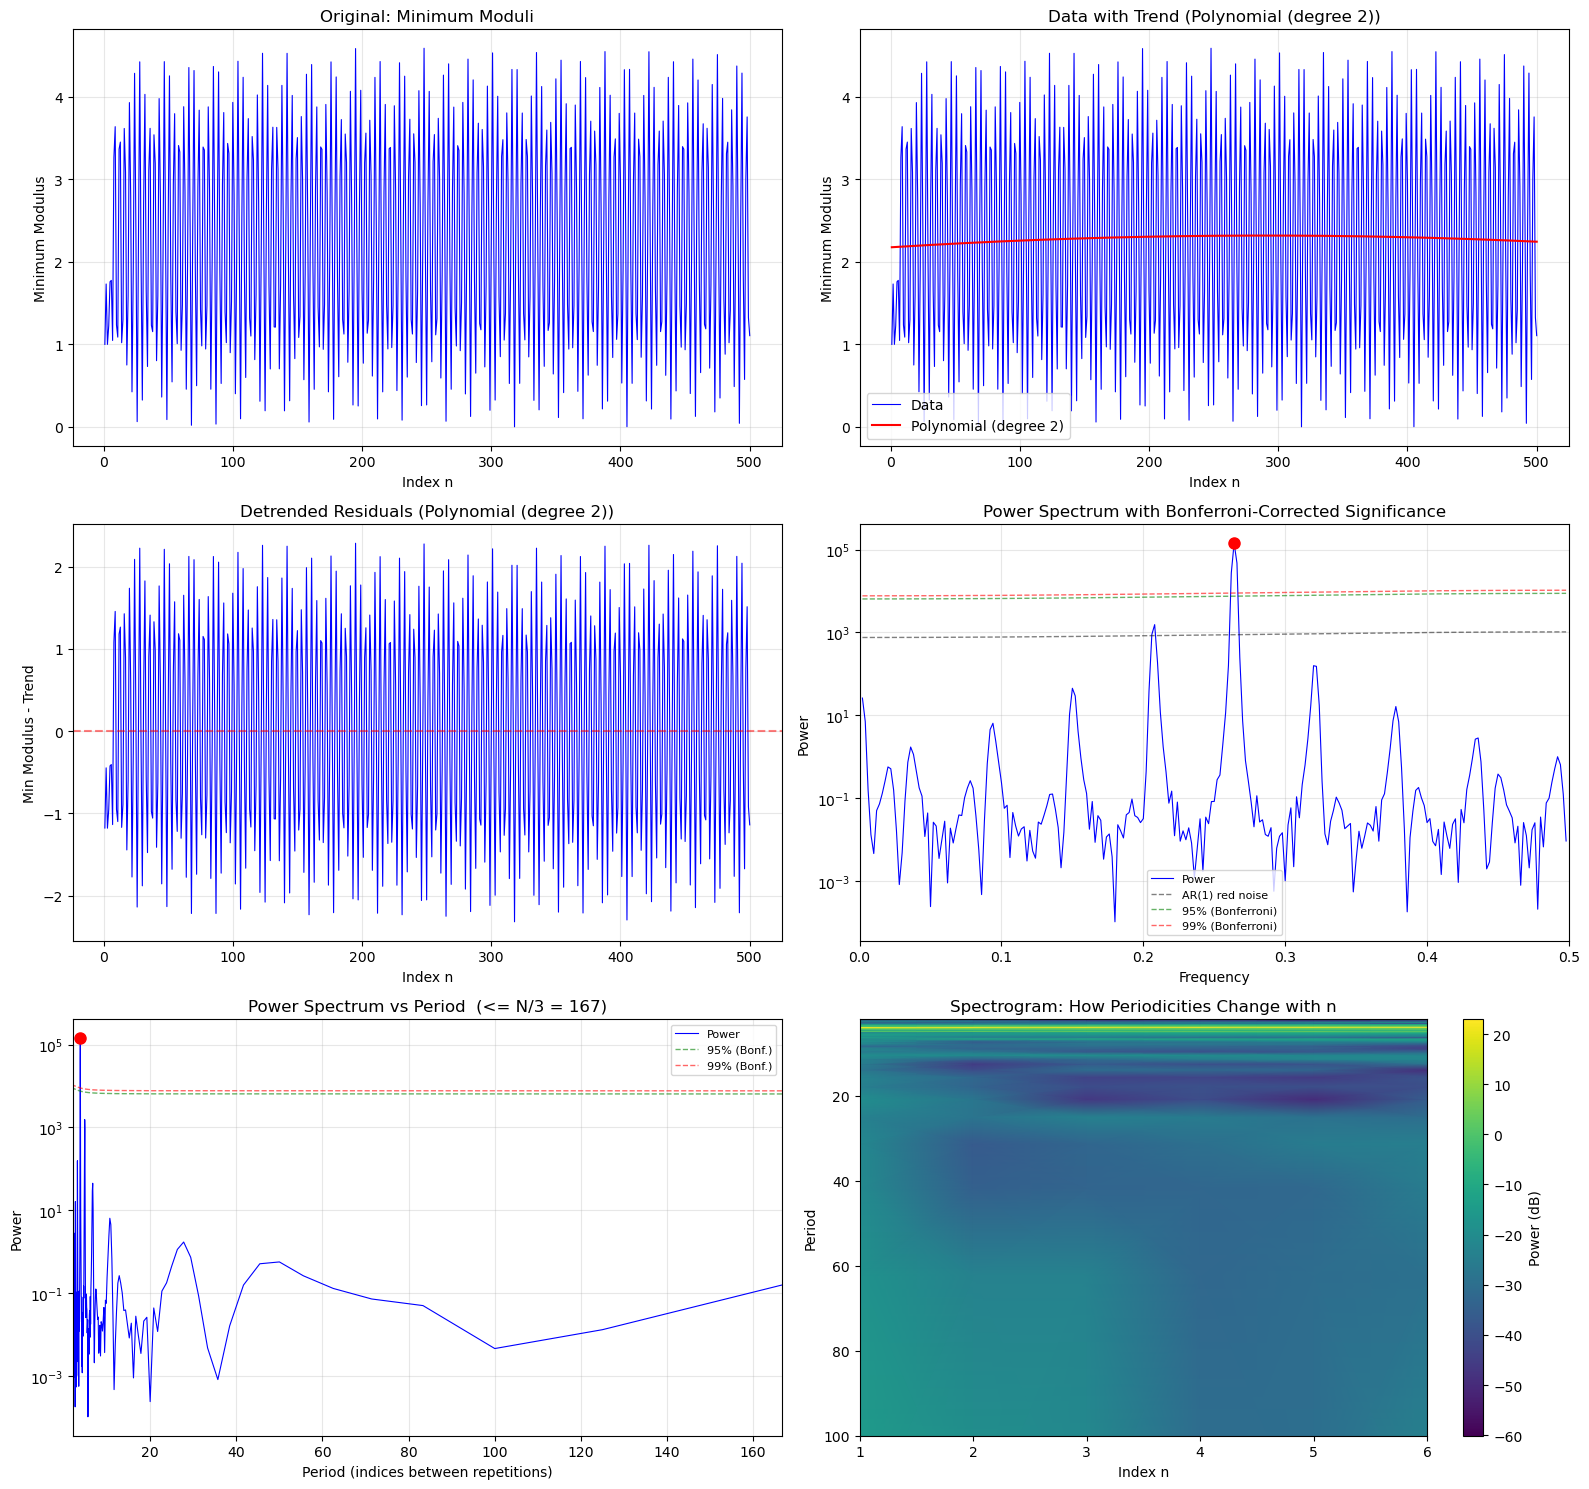


Analysis complete.


In [3]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 26
bound =3600
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0] #Cremona 26a1
expansion=data[1]
print("label:", label)
prime_list_offset=[pair for pair in expansion if is_prime(pair[0]-1)]
coeffs_list16C=[pair[1] for pair in prime_list_offset]
h16C_list=[1/2]+coeffs_list16C # h_0 = 1 required by the lemmas for the sum

level = 26
bound =505
output = elliptic_fourier_expansions(level, bound)
data=output[1]
label = data[0] #Cremona 26b1
expansion=data[1]
print("label:", label)
coeffs_list17A=[pair[1] for pair in expansion]
h17A_list=[1/2]+coeffs_list17A # h_0 = 1 required by the lemmas for the sum

len_16C=len(coeffs_list16C)
len_17A=len(coeffs_list17A)
lenn=min(len_16C,len_17A)
print("lenn:",lenn)
h_list = [a + b for a, b in zip(h16C_list[:lenn], h17A_list[:lenn])]
# Going to add them and the intial member of the sum list has to be 1.
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v8)
#
# KEY FIX: The detrending strategy now adapts to the data shape instead
# of always using a local smoother.
#
# Problem with v3/v4: A Savitzky-Golay filter with window > period
# absorbs the real oscillation into the "trend" and destroys it.
# For Figure 1 (ramp-plateau), a wide SG window was needed; for
# Figure 15B (periodic with period ~60), it was catastrophic.
#
# Solution: Use a two-stage approach:
#   Stage A: Fit a low-order polynomial (degree 2) to capture any
#            broad drift (linear/quadratic growth).  This is gentle
#            enough to never absorb oscillations with period < N/3.
#   Stage B: Check whether the polynomial residuals still have a
#            problematic trend shape (high lag-1 autocorrelation AND
#            the autocorrelation function is monotonically decaying,
#            i.e. trend-like rather than oscillation-like).  Only if
#            so, escalate to a Savitzky-Golay filter ‚Äî but cap its
#            window at max_credible_period to protect real periodicities.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. ADAPTIVE DETRENDING  (safe for both trended and periodic data)
# ==============================================================================
max_credible_period = N / 3.0

# --- Stage A: low-order polynomial (captures broad drift only) ---
poly_deg = 2
poly_coeffs = np.polyfit(indices, minmoduli, deg=poly_deg)
poly_trend = np.polyval(poly_coeffs, indices)
resid_poly = minmoduli - poly_trend

# Measure whether the residual looks "trend-like" or "oscillation-like"
# by examining the autocorrelation at several lags.
acf_lags = min(50, N // 4)
acf = np.correlate(resid_poly - resid_poly.mean(), resid_poly - resid_poly.mean(), 'full')
acf = acf[N-1:]  # positive lags only
acf = acf / acf[0]  # normalize

# A trend residual has ACF that decays monotonically from 1 toward 0.
# A periodic residual has ACF that oscillates (dips below 0, comes back up).
# Check: does the ACF cross zero within the first max_credible_period lags?
check_range = min(int(max_credible_period), len(acf))
acf_crosses_zero = np.any(acf[1:check_range] < 0)
r1_poly = np.corrcoef(resid_poly[:-1], resid_poly[1:])[0, 1]

print(f"\nStage A: degree-{poly_deg} polynomial detrend")
print(f"  lag-1 autocorrelation of residuals: {r1_poly:.4f}")
print(f"  ACF crosses zero within {check_range} lags: {acf_crosses_zero}")

# Decision: if ACF crosses zero, the residual is oscillatory (good ‚Äî
# the polynomial removed drift without eating periodicity).
# If ACF does NOT cross zero and r1 is high, there's residual trend
# that needs stronger detrending.

TREND_THRESHOLD = 0.85  # residual autocorrelation above this = still trended

if not acf_crosses_zero and abs(r1_poly) > TREND_THRESHOLD:
    # --- Stage B: local smoother needed, but window capped to protect periodicity ---
    print(f"  --> Residual is trend-like (r1={r1_poly:.4f}, no zero-crossing).")
    print(f"      Escalating to Savitzky-Golay, window capped at {int(max_credible_period)}.")

    sg_poly_order = 3
    # Cap the window: must be odd, and must not exceed max_credible_period
    max_sg_win = int(max_credible_period)
    if max_sg_win % 2 == 0:
        max_sg_win -= 1
    max_sg_win = max(max_sg_win, sg_poly_order + 2)  # minimum valid window

    candidate_windows = [w for w in range(21, max_sg_win + 1, 10) if w % 2 == 1]
    if not candidate_windows:
        candidate_windows = [max_sg_win]

    best_win, best_score = candidate_windows[0], np.inf
    for win in candidate_windows:
        trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
        resid = minmoduli - trend
        r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
        if r1 < best_score:
            best_score = r1
            best_win = win

    smooth_trend = signal.savgol_filter(minmoduli, window_length=best_win,
                                        polyorder=sg_poly_order)
    detrended = minmoduli - smooth_trend
    detrend_label = f"Savitzky-Golay (win={best_win}, order={sg_poly_order})"
    print(f"      Selected window: {best_win}")
    print(f"      lag-1 autocorrelation of residuals: {best_score:.4f}")
else:
    # Stage A was sufficient
    smooth_trend = poly_trend
    detrended = resid_poly
    detrend_label = f"Polynomial (degree {poly_deg})"
    print(f"  --> Residual is oscillatory or low-autocorrelation. "
          f"Polynomial detrend is sufficient.")

print(f"\nFinal detrending method: {detrend_label}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS  (FFT)
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

# ==============================================================================
# 5b. MULTI-SCALE FUNDAMENTAL PERIOD DETECTION
# ==============================================================================
# Waveforms can have structure at multiple scales: e.g. a sawtooth with
# period ~60 is built from small teeth with period ~3.  The FFT, naive ACF,
# and time-domain peak-finding all latch onto the finest scale because it
# has the sharpest features.
#
# Strategy: detect periodicity at MULTIPLE SCALES by progressively smoothing
# the detrended signal and re-measuring.  At each scale, compute the ACF
# and find its first peak above a quality threshold.  Collect all detected
# periods across scales and report them hierarchically.
#
# Scale 0: raw detrended signal (captures finest structure)
# Scale k: smoothed with a moving average of width 2k+1
#
# The LONGEST period detected at any scale is the fundamental; shorter
# periods are sub-cycle structure.

detected_periods = []  # list of (period, scale_label, acf_strength)

# Scales to try: raw, then moving-average windows of increasing width
# We go up to window ~ max_credible_period / 2 to avoid smoothing away
# the coarsest structure we could detect.
smooth_widths = [1]  # 1 = no smoothing (raw)
w = 3
while w < max_credible_period / 2:
    smooth_widths.append(w)
    w = max(w + 2, int(w * 1.5))
    if w % 2 == 0:
        w += 1

for sw in smooth_widths:
    if sw == 1:
        smoothed = detrended.copy()
        scale_label = "raw"
    else:
        # Moving average
        kernel = np.ones(sw) / sw
        smoothed = np.convolve(detrended, kernel, mode='same')
        scale_label = f"MA({sw})"

    # Compute ACF of smoothed signal
    sm_centered = smoothed - smoothed.mean()
    acf_sm = np.correlate(sm_centered, sm_centered, 'full')
    acf_sm = acf_sm[N-1:]
    if acf_sm[0] > 0:
        acf_sm = acf_sm / acf_sm[0]
    else:
        continue

    # Find first ACF peak above zero with lag >= sw+1
    # (don't count lags shorter than the smoothing window ‚Äî those are artifacts)
    search_start = max(2, sw + 1) if sw > 1 else 2
    search_end = min(int(max_credible_period), len(acf_sm) - 1)
    if search_start >= search_end:
        continue

    acf_slice = acf_sm[search_start:search_end+1]
    peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)

    if len(peaks_in_slice) > 0:
        best_peak = peaks_in_slice[0]  # first peak above threshold
        lag = best_peak + search_start
        strength = acf_sm[lag]

        # Check this isn't a duplicate of an already-detected period
        is_new = True
        for (prev_p, _, _) in detected_periods:
            if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                is_new = False
                break
        if is_new:
            detected_periods.append((float(lag), scale_label, float(strength)))

# Sort by period length (longest first)
detected_periods.sort(key=lambda x: x[0], reverse=True)

# The fundamental is the longest detected period; others are sub-structure
fund_period = None
fund_method = None
fund_strength = None
sub_periods = []

if detected_periods:
    fund_period = detected_periods[0][0]
    fund_method = f"multi-scale ACF ({detected_periods[0][1]})"
    fund_strength = detected_periods[0][2]
    sub_periods = detected_periods[1:]

# ==============================================================================
# 5c. REPORTING
# ==============================================================================
print("\n" + "="*75)
print(f"SIGNIFICANT FFT PEAKS  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
else:
    print("  No FFT peaks exceed the Bonferroni-corrected significance threshold.")

# --- Multi-scale period detection ---
print("\n" + "="*75)
print("MULTI-SCALE PERIOD DETECTION")
print("="*75)
if detected_periods:
    print(f"  {'Period':<12} {'Scale':<15} {'ACF strength':<15} {'Role':<20}")
    print(f"  {'-'*60}")
    for i, (p, label, strength) in enumerate(detected_periods):
        role = "FUNDAMENTAL" if i == 0 else "sub-cycle structure"
        print(f"  {p:>8.1f}    {label:<15} {strength:>10.4f}      {role}")
else:
    print("  No periodicity detected at any scale.")

# --- Harmonic analysis ---
if fund_period is not None and significant_peaks:
    print(f"\n  Harmonic analysis (FFT peaks as multiples of fundamental "
          f"= {fund_period:.1f}):")
    print(f"  {'Rank':<6} {'FFT Period':<12} {'T_fund / T_peak':<18} "
          f"{'Nearest int':<12} {'Harmonic?':<10}")
    print(f"  {'-'*70}")
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        ratio = fund_period / periods[pi]
        nearest = round(ratio)
        is_harmonic = (nearest >= 1 and
                       abs(ratio - nearest) < 0.15 * max(nearest, 1))
        tag = f"~{nearest}x" if is_harmonic else "independent"
        print(f"  {rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     "
              f"{nearest:>6}     {tag}")

# --- Summary ---
print("\n" + "="*75)
print("SUMMARY")
print("="*75)
if fund_period is not None and fund_strength > 0.2:
    print(f"  Fundamental period: {fund_period:.1f}  (via {fund_method}, "
          f"ACF strength {fund_strength:.4f})")
    if sub_periods:
        sub_str = ", ".join(f"{p:.1f}" for p, _, _ in sub_periods)
        print(f"  Sub-cycle structure at period(s): {sub_str}")
    if significant_peaks:
        dominant_fft_period = periods[significant_peaks[0][0]]
        ratio_to_fund = fund_period / dominant_fft_period
        nearest = round(ratio_to_fund)
        if nearest > 1 and abs(ratio_to_fund - nearest) < 0.15 * nearest:
            print(f"  Dominant FFT peak (period {dominant_fft_period:.2f}) is the "
                  f"~{nearest}x harmonic of the fundamental.")
            print(f"  The waveform is non-sinusoidal (sharp/angular features "
                  f"concentrate power in upper harmonics).")
        elif nearest <= 1:
            print(f"  Dominant FFT peak (period {dominant_fft_period:.2f}) matches "
                  f"the fundamental.")
elif fund_period is not None and fund_strength <= 0.2:
    print("  Weak periodicity detected (ACF strength < 0.2) ‚Äî likely not significant.")
else:
    print("  The data has no statistically significant periodicity.")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=detrend_label)
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Trend ({detrend_label})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals ({detrend_label})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)


with open('/Users/barrybrent/data2/run28may26no11.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run28may26no12.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run28may26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)
with open('/Users/barrybrent/data2/run28may26no14.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run28may26no14a.txt', 'wb') as wfile:
    pickle.dump(chi_list[:100], wfile)
with open('/Users/barrybrent/data2/run28may26no14b.txt', 'wb') as wfile:
    pickle.dump(chi_list[101:200], wfile)
with open('/Users/barrybrent/data2/run28may26no14c.txt', 'wb') as wfile:
    pickle.dump(chi_list[201:300], wfile)
with open('/Users/barrybrent/data2/run28may26no14d.txt', 'wb') as wfile:
    pickle.dump(chi_list[301:400], wfile)
with open('/Users/barrybrent/data2/run28may26no14e.txt', 'wb') as wfile:
    pickle.dump(chi_list[401:500], wfile)
with open('/Users/barrybrent/data2/run28may26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run28may26no16.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 


Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.000692 to 4.590282

SEGMENTATION  (for context; only the LAST segment is analyzed)
  Breakpoints detected (after merge): 0
  Segment 1: n = 1 to 500  (500 points)  range [0.00, 4.59]  <-- ANALYZED

FINAL SEGMENT METRICS  (n = 1 to 500, 500 points)

  [Detrending]
    linear-fit slope        : 0.000135
    residual std dev        : 1.318539
    residual / value scale  : 2.872e-01

  [Envelope]
    dynamic range (p90/p10) : 1.015
    monotonicity (|Spearman|): 0.207
    normalization applied   : False

  [Spectral baseline]
    AR(1) lag-1 autocorr rho: -0.0772
    frequency bins tested   : 247
    max credible period     : 166.7  (= n/3)

  [FFT peaks (period <= n/3), strongest first]
      Period        Power Integer(95)% thr Integer(99)% thr  Power/95%
        3.79    1.418e+05    7.524e+03    8.948e+03      18.85
        4.81    1.545e+03    7.137e+03    8.487e+03       0.22
        3.12    1.576e+02    7.942e+0

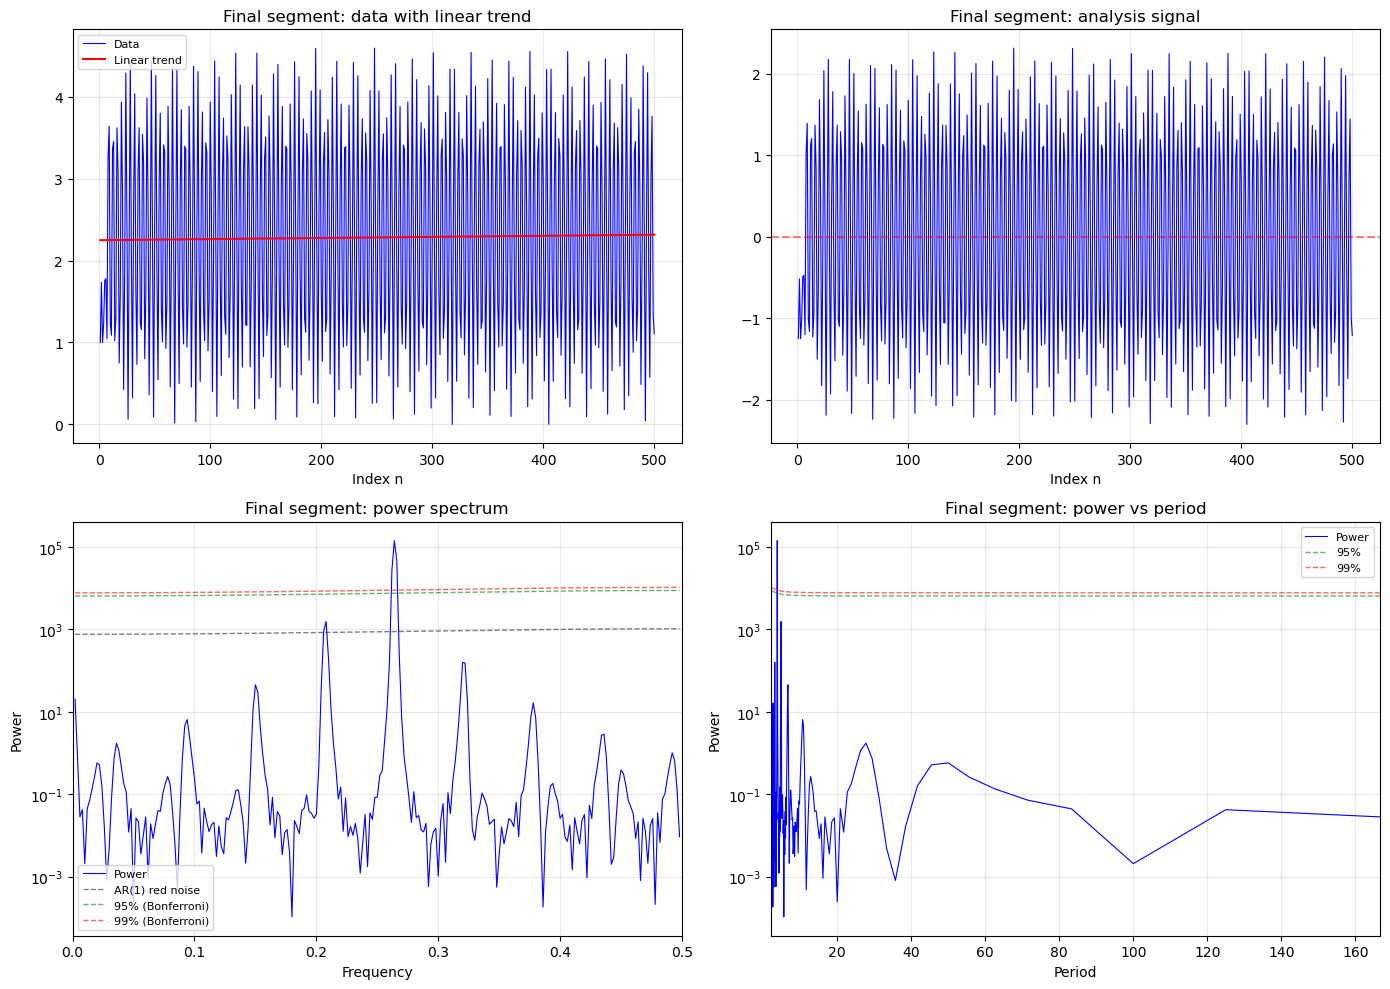


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run28may26no15.txt', 'rb') as rfile:
   mins_list = pickle.load(rfile)
# SEGMENTED FOURIER ANALYSIS OF MINIMUM MODULI  (v11)
#
# DESIGN CHANGES RELATIVE TO v10:
#
#  1. LAST SEGMENT ONLY.  The oscillation phenomenon emerges as the index n
#     grows, so only the final segment (after the last structural breakpoint)
#     is analyzed.  Earlier segments are located, reported, and plotted for
#     context only ‚Äî they are not analyzed for periodicity.
#
#  2. NO VERDICTS.  The code does not output PERIODIC / NOT PERIODIC labels.
#     It reports the raw metrics and their scores, and leaves interpretation
#     to the reader.  The metrics are:
#       - linear-detrend slope and residual standard deviation
#       - envelope dynamic range and monotonicity (and whether normalization
#         was applied)
#       - AR(1) lag-1 autocorrelation (rho)
#       - FFT peak periods with their power and the Bonferroni-corrected
#         95% / 99% red-noise thresholds at the same frequency
#       - multi-scale ACF: each detected period, the scale at which it was
#         found, and its ACF strength, with the fundamental identified
#       - the white-noise ACF reference band (1.96 / sqrt(n)), so the ACF
#         strengths can be judged against what white noise would produce
#
#  3. VISUALIZATIONS restricted to the final segment.
#
# Segmentation (level-based ruptures Pelt with l2 cost, plus slope-merge
# cleanup) and the analysis machinery are carried over unchanged from v10.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt
import ruptures as rpt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. BREAKPOINT DETECTION  (level-based, with slope-merge cleanup)
# ==============================================================================
# Used only to locate the final segment.  Detection is the ruptures Pelt
# algorithm with the l2 (mean-shift) cost on the data levels, followed by a
# slope-merge step that collapses adjacent segments of nearly equal slope
# (so an over-segmented linear ramp becomes one segment).

penalty_value = np.log(N) * np.var(minmoduli)
algo = rpt.Pelt(model="l2", min_size=max(20, N // 10)).fit(minmoduli)
breakpoints = algo.predict(pen=penalty_value)
seg_boundaries = [0] + breakpoints

_idx = np.arange(N)
_merged = True
while _merged and len(seg_boundaries) > 2:
    _merged = False
    slopes = []
    for i in range(len(seg_boundaries) - 1):
        s, e = seg_boundaries[i], seg_boundaries[i+1]
        slopes.append(np.polyfit(_idx[s:e], minmoduli[s:e], 1)[0])
    slope_scale = max(abs(max(slopes)), abs(min(slopes)), 1e-9)
    for i in range(len(slopes) - 1):
        if abs(slopes[i] - slopes[i+1]) < 0.15 * slope_scale:
            seg_boundaries.pop(i + 1)
            _merged = True
            break

n_segments = len(seg_boundaries) - 1

print(f"\n{'='*75}")
print(f"SEGMENTATION  (for context; only the LAST segment is analyzed)")
print(f"{'='*75}")
print(f"  Breakpoints detected (after merge): {n_segments - 1}")
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    si = indices[start_idx:end_idx]
    sv = minmoduli[start_idx:end_idx]
    tag = "  <-- ANALYZED" if i == n_segments - 1 else ""
    print(f"  Segment {i+1}: n = {int(si[0])} to {int(si[-1])}  "
          f"({end_idx - start_idx} points)  "
          f"range [{sv.min():.2f}, {sv.max():.2f}]{tag}")

# ==============================================================================
# 3. METRICS FOR THE FINAL SEGMENT
# ==============================================================================
last_start = seg_boundaries[-2]
last_end = seg_boundaries[-1]
seg_indices = indices[last_start:last_end]
seg_values = minmoduli[last_start:last_end]
n = len(seg_indices)

print(f"\n{'='*75}")
print(f"FINAL SEGMENT METRICS  (n = {int(seg_indices[0])} to {int(seg_indices[-1])}, "
      f"{n} points)")
print(f"{'='*75}")

metrics = {}  # collected for the visualization section

if n < 10:
    print(f"  Final segment too short ({n} points) for analysis.")
    metrics = None
else:
    max_credible_period = n / 3.0

    # --- Linear detrend ---
    coeffs = np.polyfit(seg_indices, seg_values, deg=1)
    trend = np.polyval(coeffs, seg_indices)
    detrended = seg_values - trend
    slope = coeffs[0]

    print(f"\n  [Detrending]")
    print(f"    linear-fit slope        : {slope:.6f}")
    print(f"    residual std dev        : {np.std(detrended):.6f}")

    value_scale = max(np.max(np.abs(seg_values)), 1e-30)
    resid_ratio = np.std(detrended) / value_scale
    print(f"    residual / value scale  : {resid_ratio:.3e}")

    # --- Envelope normalization ---
    abs_det = np.abs(detrended)
    env_win = max(5, min(n // 10, n // 3))
    if env_win % 2 == 0:
        env_win += 1
    env_win = min(env_win, n - 1)
    if env_win % 2 == 0:
        env_win -= 1
    if env_win < 5:
        env_win = 5

    envelope = None
    if env_win >= n:
        envelope_applied = False
        analysis_signal = detrended
        envelope_ratio = float('nan')
        env_monotonicity = float('nan')
    else:
        envelope = signal.savgol_filter(abs_det, window_length=env_win,
                                        polyorder=min(2, env_win - 1))
        env_floor = np.percentile(abs_det[abs_det > 0], 5) if np.any(abs_det > 0) else 1.0
        envelope = np.maximum(envelope, env_floor)
        env_p10 = np.percentile(envelope, 10)
        env_p90 = np.percentile(envelope, 90)
        envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0
        sp = stats.spearmanr(np.arange(n), envelope).correlation
        env_monotonicity = abs(sp) if sp == sp else 0.0
        if envelope_ratio > 3.0 and env_monotonicity > 0.6:
            analysis_signal = detrended / envelope
            envelope_applied = True
        else:
            analysis_signal = detrended
            envelope_applied = False

    print(f"\n  [Envelope]")
    print(f"    dynamic range (p90/p10) : {envelope_ratio:.3f}")
    print(f"    monotonicity (|Spearman|): {env_monotonicity:.3f}")
    print(f"    normalization applied   : {envelope_applied}")

    # --- Windowed FFT ---
    window = np.hanning(n)
    windowed = analysis_signal * window
    window_power_correction = n / np.sum(window**2)
    fft_result = np.fft.fft(windowed)
    fft_freqs = np.fft.fftfreq(n, d=1.0)
    power_spectrum = np.abs(fft_result)**2 * window_power_correction
    pos = fft_freqs > 0
    frequencies = fft_freqs[pos]
    power = power_spectrum[pos]
    periods = 1.0 / frequencies

    # --- AR(1) red-noise baseline + Bonferroni-corrected thresholds ---
    rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
    variance = np.var(analysis_signal)
    ar1_power = (variance * (1 - rho**2)) / (
        1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
    )
    ar1_power *= np.mean(power) / np.mean(ar1_power)

    credible_mask = periods <= max_credible_period
    n_tests = int(np.sum(credible_mask))
    if n_tests < 1:
        n_tests = 1
    chi2_95 = stats.chi2.ppf(1.0 - (0.05 / n_tests), df=2) / 2.0
    chi2_99 = stats.chi2.ppf(1.0 - (0.01 / n_tests), df=2) / 2.0
    conf_95 = ar1_power * chi2_95
    conf_99 = ar1_power * chi2_99

    print(f"\n  [Spectral baseline]")
    print(f"    AR(1) lag-1 autocorr rho: {rho:.4f}")
    print(f"    frequency bins tested   : {n_tests}")
    print(f"    max credible period     : {max_credible_period:.1f}  (= n/3)")

    # --- FFT peaks: report power against thresholds (no verdict) ---
    peak_idx = signal.find_peaks(power, height=0)[0]
    peak_rows = []
    for pi in peak_idx:
        if not credible_mask[pi]:
            continue
        peak_rows.append((periods[pi], power[pi], conf_95[pi], conf_99[pi],
                          power[pi] / conf_95[pi] if conf_95[pi] > 0 else float('nan')))
    peak_rows.sort(key=lambda r: r[1], reverse=True)

    print(f"\n  [FFT peaks (period <= n/3), strongest first]")
    if peak_rows:
        print(f"    {'Period':>8} {'Power':>12} {'95% thr':>12} {'99% thr':>12} "
              f"{'Power/95%':>10}")
        for per, pw, c95, c99, ratio in peak_rows[:10]:
            print(f"    {per:>8.2f} {pw:>12.3e} {c95:>12.3e} {c99:>12.3e} "
                  f"{ratio:>10.2f}")
    else:
        print(f"    (no FFT peaks with period <= n/3)")

    # --- Multi-scale ACF detection ---
    detected_periods = []
    smooth_widths = [1]
    w = 3
    while w < max_credible_period / 2:
        smooth_widths.append(w)
        w = max(w + 2, int(w * 1.5))
        if w % 2 == 0:
            w += 1

    for sw in smooth_widths:
        if sw == 1:
            smoothed = analysis_signal.copy()
            scale_label = "raw"
        else:
            kernel = np.ones(sw) / sw
            smoothed = np.convolve(analysis_signal, kernel, mode='same')
            scale_label = f"MA({sw})"
        sm_centered = smoothed - smoothed.mean()
        acf_sm = np.correlate(sm_centered, sm_centered, 'full')
        acf_sm = acf_sm[n-1:]
        if acf_sm[0] > 0:
            acf_sm = acf_sm / acf_sm[0]
        else:
            continue
        search_start = max(2, sw + 1) if sw > 1 else 2
        search_end = min(int(max_credible_period), len(acf_sm) - 1)
        if search_start >= search_end:
            continue
        slice_begin = max(0, search_start - 1)
        acf_slice = acf_sm[slice_begin:search_end+1]
        peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)
        boundary_offset = search_start - slice_begin
        if (boundary_offset not in peaks_in_slice and
                search_start < len(acf_sm) - 1 and search_start > 0):
            val = acf_sm[search_start]
            left = acf_sm[search_start - 1]
            right = acf_sm[search_start + 1]
            if val > left and val > right and val > 0.1:
                peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))
        if len(peaks_in_slice) > 0:
            true_lags = peaks_in_slice + slice_begin
            true_lags = true_lags[true_lags >= search_start]
            if len(true_lags) > 0:
                lag = int(true_lags[0])
                strength = acf_sm[lag]
                is_new = True
                for (prev_p, _, _) in detected_periods:
                    if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                        is_new = False
                        break
                if is_new:
                    detected_periods.append((float(lag), scale_label, float(strength)))

    detected_periods.sort(key=lambda x: x[0])

    best_fund_idx = 0
    if detected_periods:
        best_explained = 0
        for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
            if cand_p < 2:
                continue
            n_explained = 0
            for j, (other_p, _, _) in enumerate(detected_periods):
                if j == i:
                    n_explained += 1
                    continue
                ratio = other_p / cand_p
                nearest = round(ratio)
                if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                    n_explained += 1
            if n_explained > best_explained or (
                    n_explained == best_explained and
                    cand_str > detected_periods[best_fund_idx][2]):
                best_explained = n_explained
                best_fund_idx = i

    # White-noise reference band for the ACF (Bartlett, large-lag approx)
    acf_wn_band = 1.96 / np.sqrt(n)

    print(f"\n  [Multi-scale ACF]")
    print(f"    white-noise 95% band    : +/- {acf_wn_band:.4f}  (ACF values "
          f"within this band are consistent with noise)")
    if detected_periods:
        print(f"    {'Period':>8} {'Scale':>10} {'ACF strength':>14} "
              f"{'ACF/band':>10}  Role")
        for i, (p, label, strength) in enumerate(detected_periods):
            role = "fundamental" if i == best_fund_idx else "integer multiple"
            print(f"    {p:>8.1f} {label:>10} {strength:>14.4f} "
                  f"{strength/acf_wn_band:>10.2f}  {role}")
    else:
        print(f"    (no ACF peaks above 0.1 at any scale)")

    metrics = {
        'seg_indices': seg_indices, 'seg_values': seg_values,
        'trend': trend, 'detrended': detrended, 'envelope': envelope,
        'analysis_signal': analysis_signal, 'envelope_applied': envelope_applied,
        'frequencies': frequencies, 'power': power, 'periods': periods,
        'ar1_power': ar1_power, 'conf_95': conf_95, 'conf_99': conf_99,
        'peak_rows': peak_rows, 'detected_periods': detected_periods,
        'best_fund_idx': best_fund_idx, 'acf_wn_band': acf_wn_band,
        'max_credible_period': max_credible_period,
    }

# ==============================================================================
# 4. VISUALIZATIONS  (final segment only)
# ==============================================================================
if metrics is not None:
    m = metrics
    si = m['seg_indices']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Data with linear trend (and envelope if applied)
    axes[0, 0].plot(si, m['seg_values'], 'b-', linewidth=0.8, label='Data')
    axes[0, 0].plot(si, m['trend'], 'r-', linewidth=1.5, label='Linear trend')
    axes[0, 0].set_title(f'Final segment: data with linear trend')
    axes[0, 0].set_xlabel('Index n')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    # Analysis signal (with envelope overlay if applied)
    axes[0, 1].plot(si, m['analysis_signal'], 'b-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    title = 'Final segment: analysis signal'
    if m['envelope_applied']:
        title += ' (envelope-normalized)'
    axes[0, 1].set_title(title)
    axes[0, 1].set_xlabel('Index n')
    axes[0, 1].grid(True, alpha=0.3)

    # Power spectrum with AR(1) baseline and thresholds
    freq, pwr = m['frequencies'], m['power']
    axes[1, 0].semilogy(freq, pwr, 'b-', linewidth=0.8, label='Power')
    axes[1, 0].semilogy(freq, m['ar1_power'], 'k--', linewidth=1, alpha=0.5,
                        label='AR(1) red noise')
    axes[1, 0].semilogy(freq, m['conf_95'], 'g--', linewidth=1, alpha=0.6,
                        label='95% (Bonferroni)')
    axes[1, 0].semilogy(freq, m['conf_99'], 'r--', linewidth=1, alpha=0.6,
                        label='99% (Bonferroni)')
    axes[1, 0].set_title('Final segment: power spectrum')
    axes[1, 0].set_xlabel('Frequency')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, 0.5)

    # Power vs period
    periods = m['periods']
    max_p = m['max_credible_period']
    pmask = (periods <= max_p) & (periods >= 2)
    if np.any(pmask):
        axes[1, 1].semilogy(periods[pmask], pwr[pmask], 'b-', linewidth=0.8,
                            label='Power')
        axes[1, 1].semilogy(periods[pmask], m['conf_95'][pmask], 'g--',
                            linewidth=1, alpha=0.6, label='95%')
        axes[1, 1].semilogy(periods[pmask], m['conf_99'][pmask], 'r--',
                            linewidth=1, alpha=0.6, label='99%')
        axes[1, 1].set_xlim(2, max_p)
    axes[1, 1].set_title('Final segment: power vs period')
    axes[1, 1].set_xlabel('Period')
    axes[1, 1].set_ylabel('Power')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
